# 01 - Exploratory Data Analysis

Loads `raw_customers` from PostgreSQL and explores distributions, missing values, and churn correlations.

## Section 1 - Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
load_dotenv('../.env')
import sys; sys.path.insert(0, '..')
from src.utils.db import get_engine

sns.set_theme(style='whitegrid')

engine = get_engine()
df = pd.read_sql('SELECT * FROM raw_customers', engine)

In [2]:
df.head(5)

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn,created_at
0,CUST-00001,Male,0,Yes,No,66,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Electronic check,24.49,1745.21,No,2026-06-30 20:22:48.247682
1,CUST-00002,Female,0,Yes,No,17,No,No phone service,No,No internet service,...,No internet service,No internet service,No internet service,Month-to-month,Yes,Electronic check,22.23,381.01,No,2026-06-30 20:22:48.247682
2,CUST-00003,Female,0,No,Yes,23,Yes,Yes,Fiber optic,No,...,No,Yes,No,Month-to-month,Yes,Bank transfer (automatic),92.66,2154.94,No,2026-06-30 20:22:48.247682
3,CUST-00004,Male,0,Yes,No,51,Yes,No,DSL,No,...,No,No,No,Two year,No,Electronic check,44.74,2313.33,No,2026-06-30 20:22:48.247682
4,CUST-00005,Male,0,No,Yes,30,Yes,Yes,Fiber optic,No,...,Yes,No,No,One year,No,Mailed check,94.39,2972.55,No,2026-06-30 20:22:48.247682


In [3]:
print(f'Shape: {df.shape[0]} rows x {df.shape[1]} columns')

Shape: 7043 rows x 22 columns


In [4]:
df.dtypes

customer_id                     str
gender                          str
senior_citizen                int64
partner                         str
dependents                      str
tenure                        int64
phone_service                   str
multiple_lines                  str
internet_service                str
online_security                 str
online_backup                   str
device_protection               str
tech_support                    str
streaming_tv                    str
streaming_movies                str
contract                        str
paperless_billing               str
payment_method                  str
monthly_charges             float64
total_charges               float64
churn                           str
created_at           datetime64[us]
dtype: object

In [5]:
df.describe()

,senior_citizen,tenure,monthly_charges,total_charges,created_at
count,7043.000000,7043.000000,7043.000000,7043.000000,7043
mean,0.153770,24.472242,64.978772,1588.579221,2026-06-30 20:22:48.247681
min,0.000000,1.000000,18.000000,18.000000,2026-06-30 20:22:48.247682
25%,0.000000,11.000000,50.035000,540.825000,2026-06-30 20:22:48.247682
50%,0.000000,20.000000,70.430000,1185.970000,2026-06-30 20:22:48.247682
75%,0.000000,36.000000,85.835000,2181.665000,2026-06-30 20:22:48.247682
max,1.000000,72.000000,118.000000,7704.480000,2026-06-30 20:22:48.247682
std,0.360753,17.690278,26.048346,1389.722612,NaN


## Section 2 - Missing Values Analysis

In [6]:
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'null_count': null_counts, 'null_pct': null_pct})
missing_summary.sort_values('null_count', ascending=False)

,null_count,null_pct
customer_id,0,0.0
gender,0,0.0
senior_citizen,0,0.0
partner,0,0.0
dependents,0,0.0
tenure,0,0.0
phone_service,0,0.0
multiple_lines,0,0.0
internet_service,0,0.0
online_security,0,0.0


`total_charges` is loaded from PostgreSQL as `FLOAT`. The raw Telco-style CSV can contain blank strings for `total_charges` on customers with 0 tenure; the ingestion pipeline (`src/data/ingestion.py`) already coerces those blanks to numeric with `pd.to_numeric(..., errors='coerce').fillna(0.0)` before the row reaches the database. We re-check for that pattern here directly against the raw CSV so the notebook doesn't silently assume the fix worked.

In [7]:
raw_csv = pd.read_csv('../data/raw/customers.csv', dtype={'total_charges': str})
blank_total_charges = raw_csv['total_charges'].str.strip().eq('').sum()
print(f'Blank TotalCharges strings in raw CSV: {blank_total_charges}')
print(f'Nulls in total_charges column after DB load: {df["total_charges"].isnull().sum()}')

Blank TotalCharges strings in raw CSV: 0
Nulls in total_charges column after DB load: 0


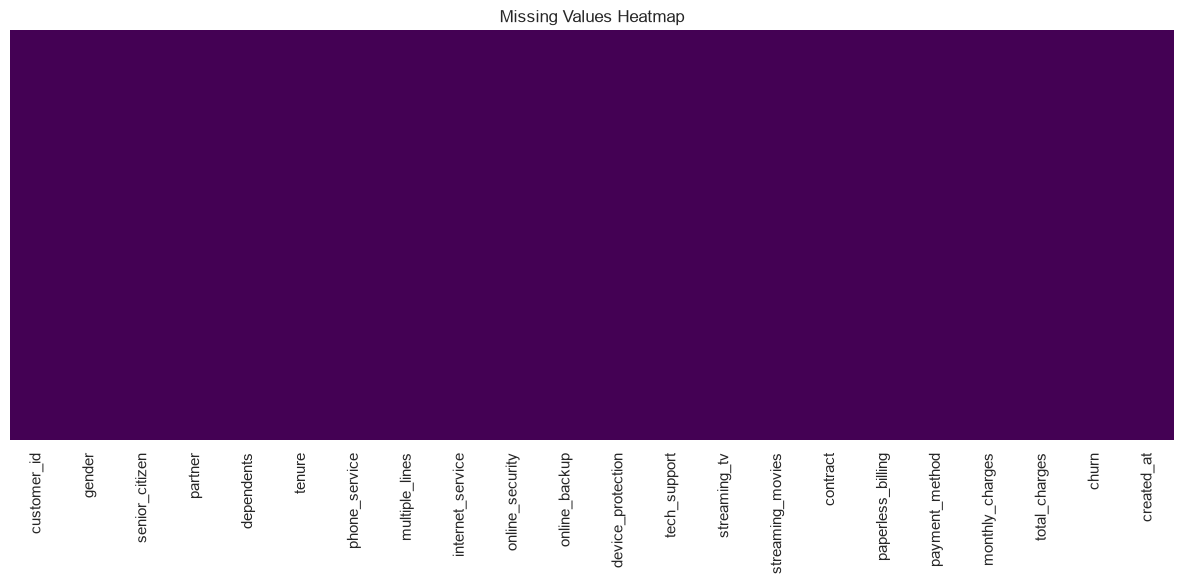

In [8]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.tight_layout()
plt.show()

**Findings - Missing Values**

- No null values were found in any of the 22 columns of `raw_customers`.
- No blank/empty-string `TotalCharges` values were found in the raw CSV either - this synthetic dataset does not reproduce the ~11 blank `TotalCharges` rows seen in the original Telco dataset (those normally belong to customers with `tenure == 0`, and this generator sets a minimum tenure of 1).
- The missing-values heatmap is uniformly empty (no highlighted cells), confirming a fully complete dataset.
- Conclusion: no imputation is required for this dataset, but the `pd.to_numeric(..., errors='coerce')` safeguard in the ingestion pipeline is kept in place in case future data pulls include blanks.